In [26]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Continue from here


In [27]:
results_model_1= pd.read_csv("/content/drive/MyDrive/extractive_textrank_results.csv")
results_model_2= pd.read_csv("/content/drive/MyDrive/extractive_textrank_results.csv")
results_model_3= pd.read_csv("/content/drive/MyDrive/extractive_textrank_results.csv")

In [28]:
print(f"Number of rows in results_model_1: {len(results_model_1)}")
print(f"Number of rows in results_model_2: {len(results_model_2)}")
print(f"Number of rows in results_model_3: {len(results_model_3)}")

Number of rows in results_model_1: 357
Number of rows in results_model_2: 357
Number of rows in results_model_3: 357


In [29]:
results_model_1

,uid,original_text,reference_summary,clean_text,clean_summary,sentences,generated_summary,rouge1,rouge2,rougeL
0,tosdr001,search encrypt does not track search history i...,this service does not track you.,search encrypt does not track search history i...,this service does not track you.,['search encrypt does not track search history...,search encrypt does not track your search hist...,0.315789,0.235294,0.315789
1,tosdr002,we also provide you additional data control op...,you can request access and deletion of persona...,we also provide you additional data control op...,you can request access and deletion of persona...,['we also provide you additional data control ...,for more information on these choices you have...,0.258065,0.068966,0.258065
2,tosdr003,rvices you grant oath the following worldwide ...,the copyright license granted to yahoo for pho...,rvices you grant oath the following worldwide ...,the copyright license granted to yahoo for pho...,['rvices you grant oath the following worldwid...,this license exists only for as long as you el...,0.290323,0.033333,0.193548
3,tosdr004,we may change these terms and conditions to re...,if you are a subscriber jagex will treat the f...,we may change these terms and conditions to re...,if you are a subscriber jagex will treat the f...,['we may change these terms and conditions to ...,please check the terms and conditions whenever...,0.545455,0.488372,0.545455
4,tosdr005,it also enables us to serve you advertising an...,the service uses your personal data to employ ...,it also enables us to serve you advertising an...,the service uses your personal data to employ ...,['it also enables us to serve you advertising ...,it also enables us to serve you advertising an...,0.250000,0.000000,0.125000
...,...,...,...,...,...,...,...,...,...,...
352,tosdr417,third party vendors including google use cooki...,this service allows tracking via third party c...,third party vendors including google use cooki...,this service allows tracking via third party c...,['third party vendors including google use coo...,third party vendors including google use cooki...,0.222222,0.058824,0.166667
353,tosdr418,the third parties that display advertisements ...,this service employs third party cookies but w...,the third parties that display advertisements ...,this service employs third party cookies but w...,['the third parties that display advertisement...,the third parties that display advertisements ...,0.178571,0.037037,0.142857
354,tosdr419,we may make use of third party service provide...,third parties may be involved in operating the...,we may make use of third party service provide...,third parties may be involved in operating the...,['we may make use of third party service provi...,to perform market research or measure website ...,0.000000,0.000000,0.000000
355,tosdr420,please be aware that we may transfer your info...,your data may be processed and stored anywhere...,please be aware that we may transfer your info...,your data may be processed and stored anywhere...,['please be aware that we may transfer your in...,please be aware that we may transfer your info...,0.192308,0.000000,0.115385


In [30]:
y_pred_model_1=results_model_1['generated_summary'].tolist()
y_true_model_1=results_model_1['clean_summary'].tolist()
y_pred_model_2=results_model_2['generated_summary'].tolist()
y_true_model_2=results_model_2['clean_summary'].tolist()
y_pred_model_3=results_model_3['generated_summary'].tolist()
y_true_model_3=results_model_3['clean_summary'].tolist()


In [31]:
!pip install bert_score

In [32]:
import pandas as pd
from bert_score import score

print("Calculating BertScore...")

# Lists to store all individual scores
all_precision_scores = []
all_recall_scores = []
all_f1_scores = []

# Lists to store system-level (mean) scores for each model part
system_precision_scores = []
system_recall_scores = []
system_f1_scores = []

# List of prediction/true pairs for each model part
model_data_parts = [
    (y_pred_model_1, y_true_model_1),
    (y_pred_model_2, y_true_model_2),
    (y_pred_model_3, y_true_model_3)
]

# Iterate through each model's predictions and true summaries
for i, (y_pred, y_true) in enumerate(model_data_parts):
    print(f"\nCalculating BertScore for model part {i+1}...")
    # score returns (P, R, F1) tensors for each example
    P_scores, R_scores, F1_scores = score(y_pred, y_true, lang="en", verbose=True)

    # Append individual scores to the master lists
    all_precision_scores.extend(P_scores.tolist())
    all_recall_scores.extend(R_scores.tolist())
    all_f1_scores.extend(F1_scores.tolist())

    # Store system-level scores
    system_precision_scores.append(P_scores.mean().item())
    system_recall_scores.append(R_scores.mean().item())
    system_f1_scores.append(F1_scores.mean().item())

    # Print system-level scores for the current model part
    print(f"\nSystem level BertScore for model part {i+1}:")
    print(f"Precision: {system_precision_scores[-1]:.4f}")
    print(f"Recall: {system_recall_scores[-1]:.4f}")
    print(f"F1 Score: {system_f1_scores[-1]:.4f}")

# Create a DataFrame for system-level scores
system_scores_df = pd.DataFrame({
    'Model Part': [f'Model {j+1}' for j in range(len(model_data_parts))],
    'Precision': system_precision_scores,
    'Recall': system_recall_scores,
    'F1 Score': system_f1_scores
})

print("\nAggregated System-Level BertScores:")
display(system_scores_df)

# Save system-level scores to a CSV file in Google Drive
system_output_csv_path = '/content/drive/MyDrive/bert_system_scores_summary.csv'
system_scores_df.to_csv(system_output_csv_path, index=False)
print(f"\nAggregated System-Level BertScores saved to {system_output_csv_path}")


# Now, add the collected individual scores back to the original results_df_local
# Ensure the lengths match before assigning
if len(results_df_local) == len(all_f1_scores):
    results_df_local['bert_score_precision'] = all_precision_scores
    results_df_local['bert_score_recall'] = all_recall_scores
    results_df_local['bert_score_f1'] = all_f1_scores
    print("\nIndividual BertScores added to results_df_local.")
else:
    print("\nError: Length mismatch between results_df_local and calculated BertScores. Cannot add to DataFrame.")
    print(f"results_df_local length: {len(results_df_local)}, BertScores length: {len(all_f1_scores)}")

print("\nFirst 5 rows of the DataFrame with Individual BertScores:")
display(results_df_local.head())

# Save the DataFrame with BertScores to a CSV file in Google Drive
output_csv_path = '/content/drive/MyDrive/Bert_scores.csv'
results_df_local.to_csv(output_csv_path, index=False)
print(f"\nDataFrame with Individual BertScores saved to {output_csv_path}")

Calculating BertScore...

Calculating BertScore for model part 1...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/9 [00:00<?, ?it/s]

...

done in 5.24 seconds, 68.08 sentences/sec

System level BertScore for model part 3:
Precision: 0.8437
Recall: 0.8817
F1 Score: 0.8620

Aggregated System-Level BertScores:


,Model Part,Precision,Recall,F1 Score
0,Model 1,0.843666,0.88167,0.861966
1,Model 2,0.843666,0.88167,0.861966
2,Model 3,0.843666,0.88167,0.861966



Aggregated System-Level BertScores saved to /content/drive/MyDrive/bert_system_scores_summary.csv

Error: Length mismatch between results_df_local and calculated BertScores. Cannot add to DataFrame.
results_df_local length: 357, BertScores length: 1071

First 5 rows of the DataFrame with Individual BertScores:


,uid,original_text,reference_summary,clean_text,clean_summary,sentences,generated_summary,rouge1,rouge2,rougeL,bert_score_precision,bert_score_recall,bert_score_f1
0,tosdr001,search encrypt does not track search history i...,this service does not track you.,search encrypt does not track search history i...,this service does not track you.,['search encrypt does not track search history...,search encrypt does not track your search hist...,0.315789,0.235294,0.315789,0.866468,0.928329,0.896332
1,tosdr002,we also provide you additional data control op...,you can request access and deletion of persona...,we also provide you additional data control op...,you can request access and deletion of persona...,['we also provide you additional data control ...,for more information on these choices you have...,0.258065,0.068966,0.258065,0.845657,0.892247,0.868327
2,tosdr003,rvices you grant oath the following worldwide ...,the copyright license granted to yahoo for pho...,rvices you grant oath the following worldwide ...,the copyright license granted to yahoo for pho...,['rvices you grant oath the following worldwid...,this license exists only for as long as you el...,0.290323,0.033333,0.193548,0.855940,0.849223,0.852568
3,tosdr004,we may change these terms and conditions to re...,if you are a subscriber jagex will treat the f...,we may change these terms and conditions to re...,if you are a subscriber jagex will treat the f...,['we may change these terms and conditions to ...,please check the terms and conditions whenever...,0.545455,0.488372,0.545455,0.903421,0.952021,0.927084
4,tosdr005,it also enables us to serve you advertising an...,the service uses your personal data to employ ...,it also enables us to serve you advertising an...,the service uses your personal data to employ ...,['it also enables us to serve you advertising ...,it also enables us to serve you advertising an...,0.250000,0.000000,0.125000,0.848520,0.874076,0.861108



DataFrame with Individual BertScores saved to /content/drive/MyDrive/Bert_scores.csv


In [33]:
!pip install -q evaluate

In [34]:
!pip install rouge_score

In [35]:
import evaluate
import pandas as pd

print("Calculating ROUGE scores...")

# Load the ROUGE metric
rouge = evaluate.load("rouge")

# Lists to store system-level ROUGE scores for each model part
system_rouge1_scores = []
system_rouge2_scores = []
system_rougeL_scores = []
system_rougeLsum_scores = []

# List of prediction/true pairs for each model part (from previous cells)
model_data_parts = [
    (y_pred_model_1, y_true_model_1),
    (y_pred_model_2, y_true_model_2),
    (y_pred_model_3, y_true_model_3)
]

# Iterate through each model's predictions and true summaries
for i, (y_pred, y_true) in enumerate(model_data_parts):
    print(f"\nCalculating ROUGE for model part {i+1}...")
    # Compute ROUGE scores for the current model part
    results_rouge = rouge.compute(predictions=y_pred, references=y_true)

    # Store system-level scores
    system_rouge1_scores.append(results_rouge['rouge1'])
    system_rouge2_scores.append(results_rouge['rouge2'])
    system_rougeL_scores.append(results_rouge['rougeL'])
    system_rougeLsum_scores.append(results_rouge['rougeLsum'])

    # Print system-level scores for the current model part
    print(f"System level ROUGE scores for model part {i+1}:")
    print(f"ROUGE-1: {results_rouge['rouge1']:.4f}")
    print(f"ROUGE-2: {results_rouge['rouge2']:.4f}")
    print(f"ROUGE-L: {results_rouge['rougeL']:.4f}")
    print(f"ROUGE-Lsum: {results_rouge['rougeLsum']:.4f}")

# Create a DataFrame for aggregated system-level ROUGE scores
system_rouge_df = pd.DataFrame({
    'Model Part': [f'Model {j+1}' for j in range(len(model_data_parts))],
    'ROUGE-1': system_rouge1_scores,
    'ROUGE-2': system_rouge2_scores,
    'ROUGE-L': system_rougeL_scores,
    'ROUGE-Lsum': system_rougeLsum_scores
})

print("\nAggregated System-Level ROUGE Scores:")
display(system_rouge_df)

# Save system-level ROUGE scores to a CSV file in Google Drive
rouge_output_csv_path = '/content/drive/MyDrive/rouge_system_scores_summary.csv'
system_rouge_df.to_csv(rouge_output_csv_path, index=False)
print(f"\nAggregated System-Level ROUGE Scores saved to {rouge_output_csv_path}")

Calculating ROUGE scores...

Calculating ROUGE for model part 1...
System level ROUGE scores for model part 1:
ROUGE-1: 0.2085
ROUGE-2: 0.0623
ROUGE-L: 0.1693
ROUGE-Lsum: 0.1690

Calculating ROUGE for model part 2...
System level ROUGE scores for model part 2:
ROUGE-1: 0.2085
ROUGE-2: 0.0623
ROUGE-L: 0.1693
ROUGE-Lsum: 0.1690

Calculating ROUGE for model part 3...
System level ROUGE scores for model part 3:
ROUGE-1: 0.2085
ROUGE-2: 0.0623
ROUGE-L: 0.1693
ROUGE-Lsum: 0.1690

Aggregated System-Level ROUGE Scores:


,Model Part,ROUGE-1,ROUGE-2,ROUGE-L,ROUGE-Lsum
0,Model 1,0.208481,0.062283,0.169292,0.168971
1,Model 2,0.208481,0.062283,0.169292,0.168971
2,Model 3,0.208481,0.062283,0.169292,0.168971



Aggregated System-Level ROUGE Scores saved to /content/drive/MyDrive/rouge_system_scores_summary.csv


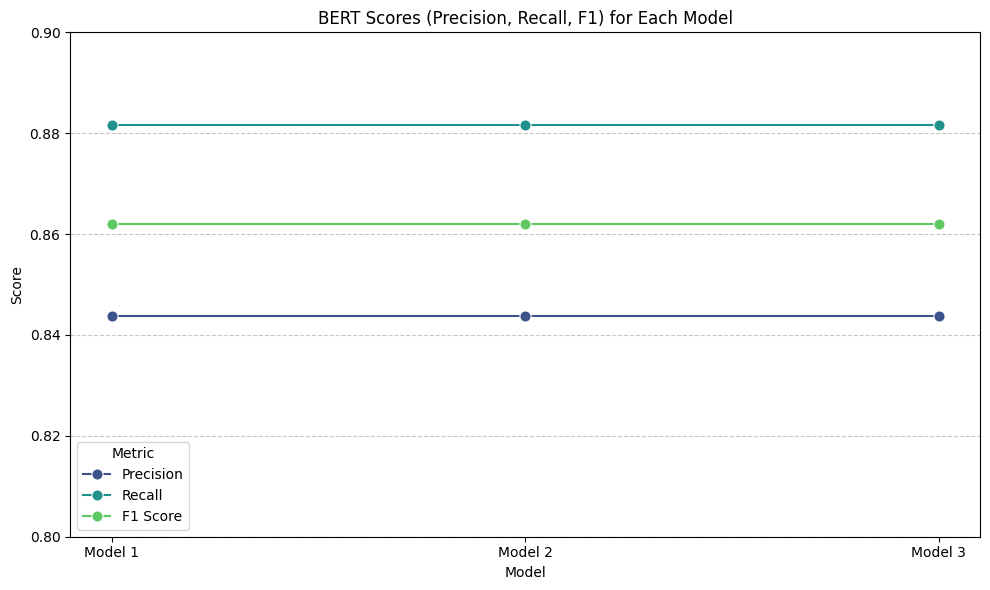

BERT scores line graph saved to /content/drive/MyDrive/bert_all_scores_line.png


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Melt the BERT system scores DataFrame for plotting multiple metrics
bert_melted_df = system_scores_df.melt(id_vars=['Model Part'],
                                       value_vars=['Precision', 'Recall', 'F1 Score'],
                                       var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Model Part', y='Score', hue='Metric', data=bert_melted_df,
             marker='o', markersize=8, palette='viridis')
plt.title('BERT Scores (Precision, Recall, F1) for Each Model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.8, 0.9) # Adjust y-limit for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bert_all_scores_line.png')
plt.show()
print("BERT scores line graph saved to /content/drive/MyDrive/bert_all_scores_line.png")

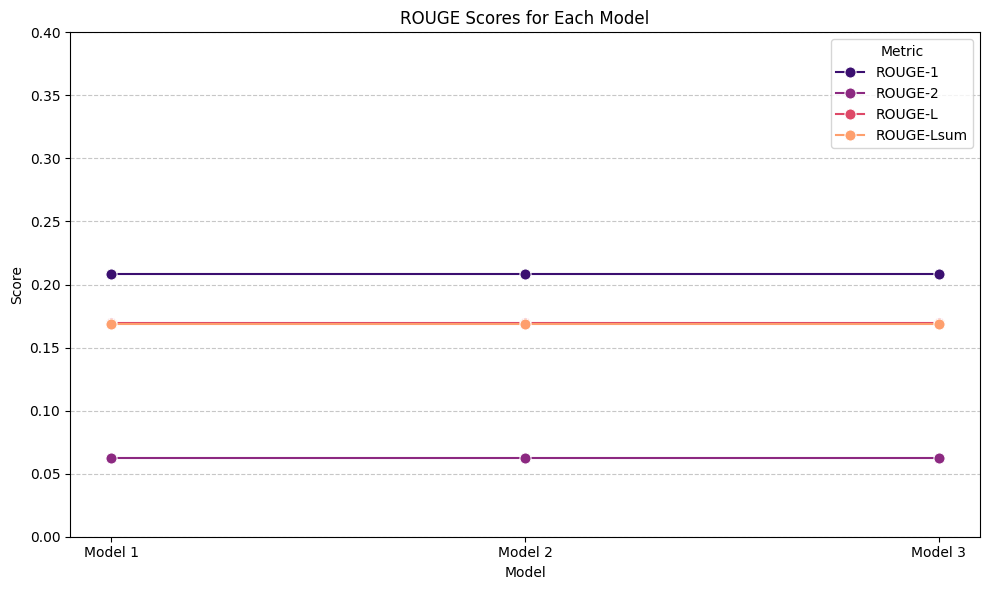

ROUGE scores line graph saved to /content/drive/MyDrive/rouge_all_scores_line.png


In [37]:
# Melt the ROUGE system scores DataFrame for plotting multiple metrics
rouge_melted_df = system_rouge_df.melt(id_vars=['Model Part'],
                                        value_vars=['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-Lsum'],
                                        var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Model Part', y='Score', hue='Metric', data=rouge_melted_df,
             marker='o', markersize=8, palette='magma')
plt.title('ROUGE Scores for Each Model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 0.4) # Adjust y-limit for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rouge_all_scores_line.png')
plt.show()
print("ROUGE scores line graph saved to /content/drive/MyDrive/rouge_all_scores_line.png")

### Error Analysis: Identifying Low-Scoring Summaries

Examine some of the summaries that received the lowest BERT F1 scores to understand their failure modes. This manual inspection is crucial for qualitative error analysis.

In [38]:
import pandas as pd

# Sort the DataFrame by 'bert_score_f1' in ascending order to find the lowest scores
lowest_f1_summaries = results_df_local.sort_values(by='bert_score_f1', ascending=True)

print("Top 10 Summaries with Lowest BERT F1 Scores:")
# Display relevant columns for manual inspection, excluding 'document_id' as it was dropped
display(lowest_f1_summaries[['original_text', 'generated_summary', 'clean_summary', 'bert_score_f1']].head(10))


error_analysis_output_csv_path = '/content/drive/MyDrive/error_analysis.csv'
lowest_f1_summaries.to_csv(error_analysis_output_csv_path, index=False)
print(f"\nAggregated low f1 scored docs saved to {error_analysis_output_csv_path}")
# You can adjust the number of displayed rows (e.g., .head(20)) or filter by a specific threshold:
# threshold = 0.8
# failure_cases = results_df_local[results_df_local['bert_score_f1'] < threshold]
# print(f"\nSummaries with BERT F1 Score below {threshold}:")
# display(failure_cases[['original_document', 'generated_summary', 'true_summary', 'bert_score_f1']].head())

Top 10 Summaries with Lowest BERT F1 Scores:


,original_text,generated_summary,clean_summary,bert_score_f1
297,to the extent permitted by applicable law you ...,b your violation of any term of this agreement...,defend indemnify hold harmless survives termin...,0.797839
34,we also allow specific partners to collect inf...,we also allow specific partners to collect inf...,the service may use tracking pixels web beacon...,0.803781
111,if you post member content to our services you...,if you post member content to our services you...,may retain certain information as required by ...,0.806070
8,sharing data like address book contacts anonym...,you can opt out anytime.,the privacy policy states sharing data like an...,0.806493
143,5 5 by creating uploading posting sending rece...,5 5 by creating uploading posting sending rece...,this service can use your content for all thei...,0.811295
187,we do not guarantee that any of the informatio...,this also includes but is not limited to date ...,the service does not guarantee accuracy or rel...,0.815467
293,either party may terminate the agreement i if ...,either party may terminate the agreement i if ...,user suspension from the service will be fair ...,0.816392
28,technical data which may include url informati...,technical data which may include url informati...,the service may use tracking pixels web beacon...,0.817643
304,cookies are small data files that are commonly...,like cookies advertising identifiers are used ...,cookies are required.,0.819193
338,device information as described below we colle...,device information as described below we colle...,collects all data you send username email cred...,0.819201



Aggregated low f1 scored docs saved to /content/drive/MyDrive/error_analysis.csv
